# Exercise 7: Text Generation with RNN - SOLUTION

Complete solution with notes to help, and a hint to advanced techniques.

---

## Learning Objectives
✓ Character-level text representation

✓ Sequence-to-sequence modeling

✓ Temperature-based sampling

✓ Text generation techniques

## Expected Outcomes
- After 20 epochs: Coherent words and basic grammar
- After 50+ epochs: Shakespeare-like sentences
- Training time: ~10-15 minutes for 20 epochs

## Advanced Exercise
- Extend the exercise by completing the advance task suggested at the end

## Step 0: Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import random

print(f"TensorFlow version: {tf.__version__}")

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0


## Step 1: Load Shakespeare Text

**Why Shakespeare?**
- Rich vocabulary
- Distinctive style
- ~1MB of text (good size for learning)
- Fun to generate!

In [2]:
# Download Shakespeare dataset
path = keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

with open(path, 'r', encoding='utf-8') as f:
    text = f.read()

# Text statistics
print("📊 Text Statistics")
print("="*50)
print(f"Total characters: {len(text):,}")
print(f"Total words: {len(text.split()):,}")
print(f"Total lines: {len(text.splitlines()):,}")
print(f"\nFirst 300 characters:\n{text[:300]}")
print(f"\nLast 200 characters:\n{text[-200:]}")

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📊 Text Statistics
Total characters: 1,115,394
Total words: 202,651
Total lines: 40,000

First 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us

Last 200 characters:
ge repose, to be asleep
With eyes wide open; standing, speaking, moving,
And yet so fast asleep.

ANTONIO:
Noble Sebastian,
Thou let'st thy fortune sleep--die, rather; wink'st
Whiles thou art waking.



## Step 2: Create Character Vocabulary

**Teaching Point:** Character-level models:
- Smaller vocabulary (~65 characters vs ~50,000 words)
- Can generate novel words
- Learn spelling and punctuation
- Require longer sequences

In [3]:
# Get unique characters
chars = sorted(set(text))
vocab_size = len(chars)

print(f"Vocabulary size: {vocab_size}")
print(f"\nAll characters:")
print(repr(''.join(chars)))

# Create character mappings
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for idx, char in enumerate(chars)}

# Show some mappings
print(f"\nExample mappings:")
for char in ['a', 'A', ' ', '\n', '.']:
    if char in char_to_idx:
        print(f"  '{char}' → {char_to_idx[char]}")

Vocabulary size: 65

All characters:
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Example mappings:
  'a' → 39
  'A' → 13
  ' ' → 1
  '
' → 0
  '.' → 8


## Step 3: Create Training Sequences

**Sliding Window Approach:**
```
Text: "Hello world"
seq_length=5, step=1

Input: "Hello" → Target: " "
Input: "ello " → Target: "w"
Input: "llo w" → Target: "o"
...
```

In [4]:
# Create sequences
seq_length = 40  # Characters to use for prediction
step = 3  # Stride (overlap sequences)

sequences = []
next_chars = []

for i in range(0, len(text) - seq_length, step):
    sequences.append(text[i:i+seq_length])
    next_chars.append(text[i+seq_length])

print(f"Number of sequences: {len(sequences):,}")
print(f"\n📝 Examples:")
for i in range(3):
    print(f"\nSequence {i+1}:")
    print(f"  Input:  '{sequences[i]}'")
    print(f"  Target: '{next_chars[i]}'")

Number of sequences: 371,785

📝 Examples:

Sequence 1:
  Input:  'First Citizen:
Before we proceed any fur'
  Target: 't'

Sequence 2:
  Input:  'st Citizen:
Before we proceed any furthe'
  Target: 'r'

Sequence 3:
  Input:  'Citizen:
Before we proceed any further, '
  Target: 'h'


## Step 4: Vectorize (One-Hot Encoding)

**One-Hot Encoding:**
```
'a' → [1, 0, 0, 0, ...] (vocab_size dimension)
'b' → [0, 1, 0, 0, ...]
```

**Memory consideration:**
- Input shape: (samples, seq_length, vocab_size)
- With 200K sequences: ~500MB of RAM

In [5]:
print("Vectorizing sequences...")

# Create arrays
X = np.zeros((len(sequences), seq_length, vocab_size), dtype=np.bool_)
y = np.zeros((len(sequences), vocab_size), dtype=np.bool_)

# One-hot encode
for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_idx[char]] = 1
    y[i, char_to_idx[next_chars[i]]] = 1

    if i % 50000 == 0:
        print(f"  Processed {i:,} sequences...")

print(f"\n✅ Vectorization complete!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Memory: ~{(X.nbytes + y.nbytes) / 1024**2:.0f} MB")

Vectorizing sequences...
  Processed 0 sequences...
  Processed 50,000 sequences...
  Processed 100,000 sequences...
  Processed 150,000 sequences...
  Processed 200,000 sequences...
  Processed 250,000 sequences...
  Processed 300,000 sequences...
  Processed 350,000 sequences...

✅ Vectorization complete!
X shape: (371785, 40, 65)
y shape: (371785, 65)
Memory: ~945 MB


## Step 5: Build the Model

**Architecture:**
- LSTM(128): Learn temporal patterns
- Dense(vocab_size, softmax): Output probability distribution over characters

**Why this architecture?**
- 128 LSTM units: Good balance of capacity vs speed
- Single layer: Simpler, trains faster
- Softmax: Interprets as probability distribution

In [6]:
model = keras.Sequential([
    layers.LSTM(128, input_shape=(seq_length, vocab_size), name='lstm'),
    layers.Dense(vocab_size, activation='softmax', name='output')
], name='Text_Generator')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print(f"\n💡 Model has {model.count_params():,} trainable parameters")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Text_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 65)             │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,713 (420.75 KB)

 Trainable params: 107,713 (420.75 KB)

 Non-trainable params: 0 (0.00 B)


💡 Model has 107,713 trainable parameters


## Step 6: Train the Model

**Training Tips:**
- Start with 10-20 epochs
- Accuracy of 40-50% is good (65 possible characters)
- Loss should decrease steadily

In [7]:
# Train
history = model.fit(
    X, y,
    batch_size=128,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.2618 - loss: 2.7506 - val_accuracy: 0.3818 - val_loss: 2.1362
Epoch 2/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4097 - loss: 2.0457 - val_accuracy: 0.4132 - val_loss: 1.9899
Epoch 3/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.4491 - loss: 1.8809 - val_accuracy: 0.4342 - val_loss: 1.9130
Epoch 4/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.4758 - loss: 1.7780 - val_accuracy: 0.4496 - val_loss: 1.8659
Epoch 5/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.4950 - loss: 1.7072 - val_accuracy: 0.4622 - val_loss: 1.8303
Epoch 6/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5082 - loss: 1.6543 - val_accuracy: 0.4709 - val_loss: 1.8014
Epoch 7/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5199 - loss: 1.6125 - val_accuracy: 0.4777 - val_loss: 1.7799
Epoch 8/20
2615/2615 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5279 - loss: 1

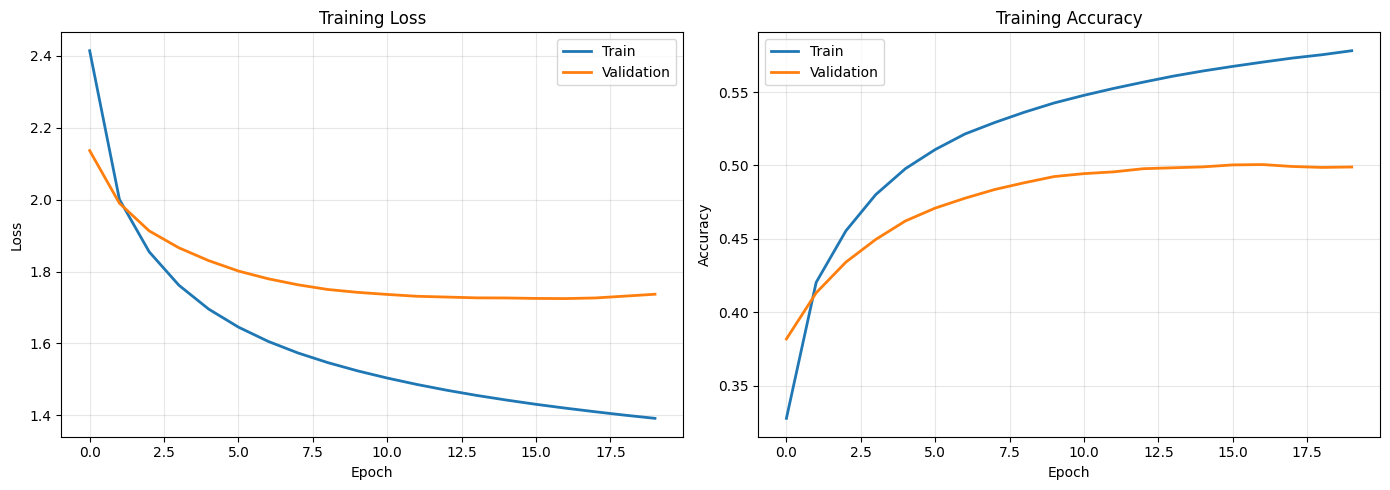


Final training accuracy: 57.81%
Final validation accuracy: 49.89%


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

## Step 7: Text Generation Functions

**Temperature Parameter:**
- **Low (0.2-0.5):** Conservative, repetitive, grammatically correct
- **Medium (0.5-0.8):** Balanced creativity and coherence
- **High (0.8-1.5):** Creative, surprising, may be nonsensical

**Math:** `probabilities = softmax(logits / temperature)`

In [9]:
def sample(preds, temperature=1.0):
    """
    Sample an index from probability array with temperature.

    Args:
        preds: Probability distribution
        temperature: Controls randomness (higher = more random)

    Returns:
        Sampled character index
    """
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-10) / temperature  # Add small constant to avoid log(0)
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)


def generate_text(seed_text, length=400, temperature=0.5):
    """
    Generate text character by character.

    Args:
        seed_text: Starting text (must be >= seq_length)
        length: Number of characters to generate
        temperature: Sampling temperature

    Returns:
        Generated text
    """
    # Ensure seed is long enough
    if len(seed_text) < seq_length:
        seed_text = seed_text + ' ' * (seq_length - len(seed_text))

    generated = seed_text

    for i in range(length):
        # Prepare input: one-hot encode last seq_length characters
        sampled = np.zeros((1, seq_length, vocab_size))
        for t, char in enumerate(generated[-seq_length:]):
            if char in char_to_idx:
                sampled[0, t, char_to_idx[char]] = 1

        # Predict next character
        preds = model.predict(sampled, verbose=0)[0]
        next_idx = sample(preds, temperature)
        next_char = idx_to_char[next_idx]

        # Append to generated text
        generated += next_char

    return generated


print("✅ Text generation functions ready!")

✅ Text generation functions ready!


## Step 8: Generate Shakespeare!

Let's compare different temperatures

In [10]:
# Seed text from Shakespeare
seed = "To be or not to be, that is the questio"

temperatures = [0.2, 0.5, 0.8, 1.2]

for temp in temperatures:
    print("\n" + "="*70)
    print(f"Temperature: {temp}")
    print("="*70)

    generated = generate_text(seed, length=400, temperature=temp)
    print(generated)
    print("\n" + "-"*70)


Temperature: 0.2
To be or not to be, that is the questio sheet the blood
That the body with a blood and man be well;
And the way the fight of the peace to the heaven
That when the this will shall be the bound with her.

KING RICHARD II:
So many have the body with the petitent.

KING RICHARD II:
The fear of the soul of the poor souls,
And the blood and the blood and thy father,
And the way the world the mother to the
chain and so much a blood and my brot

----------------------------------------------------------------------

Temperature: 0.5
To be or not to be, that is the questio strithes
I love thee for your good, or are that the poser
And my more good love and our brother,
And yet so forth his son this propets and so.

PRINCE EDWARD:
Now, father with my lord.

CAPULET:
O shall have not end with men and your friend.

KING RICHARD II:
But my good and man and see him him.

MERCUTIO:
The little parton gates, my land on the
rovilation of many
As for this that thou hast be say

---------

## Step 9: Interactive Generation

In [11]:
# Generate from custom prompts
prompts = [
    "O Romeo, Romeo, wherefore art thou Rome",
    "All the world's a stage, and all the me",
    "Friends, Romans, countrymen, lend me yo"
]

for prompt in prompts:
    print("\n" + "="*70)
    print(f"Prompt: {prompt}")
    print("="*70)
    result = generate_text(prompt, length=200, temperature=0.6)
    print(result)


Prompt: O Romeo, Romeo, wherefore art thou Rome
O Romeo, Romeo, wherefore art thou Rome and
Ox come to her soul so not and my lively
But and that have follow for your grace?

JULIET:
O well may be so looks, the lose and friend
Talk agains the earth honour in the send
With all of this tha

Prompt: All the world's a stage, and all the me
All the world's a stage, and all the me and of him.

EDWARD:
Now or a baliful and that with a blood,
And accorners to my brothers that your hands,
When she is hew the world with your sitter.

LADY CAPULET:
O, then, my pervolle as my not for

Prompt: Friends, Romans, countrymen, lend me yo
Friends, Romans, countrymen, lend me yo rear should be well
To see the way, as that but when have not them
A man be such a posice with with a fais
The night's father, now, but these may be his letters.

CLARENCE:
O, thy scopt alterous grace


## Bonus: Deeper Model for Better Results

In [12]:
# Build a deeper model
model_deep = keras.Sequential([
    layers.LSTM(256, return_sequences=True, input_shape=(seq_length, vocab_size)),
    layers.Dropout(0.2),
    layers.LSTM(256),
    layers.Dropout(0.2),
    layers.Dense(vocab_size, activation='softmax')
], name='Deep_Text_Generator')

model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Deeper model created!")
print(f"Parameters: {model_deep.count_params():,}")
print("\n💡 This model will produce better results but takes longer to train.")

Deeper model created!
Parameters: 871,745

💡 This model will produce better results but takes longer to train.
